First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null 

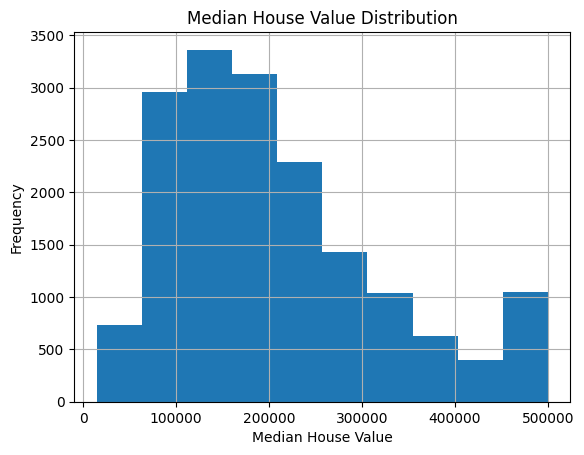

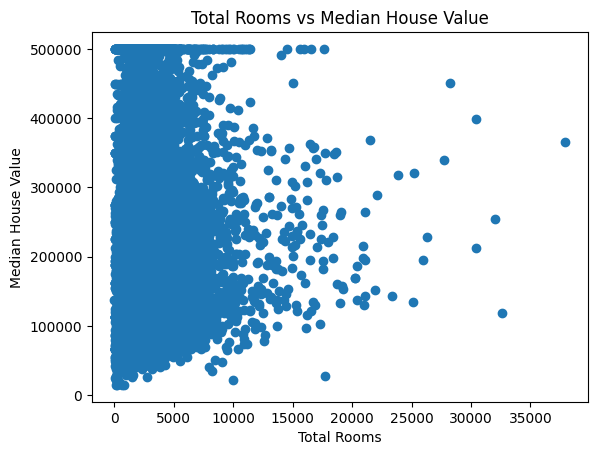


Linear Regression Performance:
RMSE: 68078.32552452553
R2 Score: 0.6636396350243869

Random Forest Performance:
RMSE: 49414.54590479251
R2 Score: 0.822786541134775
XGBoost
R2: 0.8283342976753205
RMSE: 48634.92214251076

Feature Importance:
              Feature  Importance
7       median_income    0.515105
0           longitude    0.167252
1            latitude    0.155041
2  housing_median_age    0.058206
5          population    0.034932
3         total_rooms    0.024799
4      total_bedrooms    0.024678
6          households    0.019987


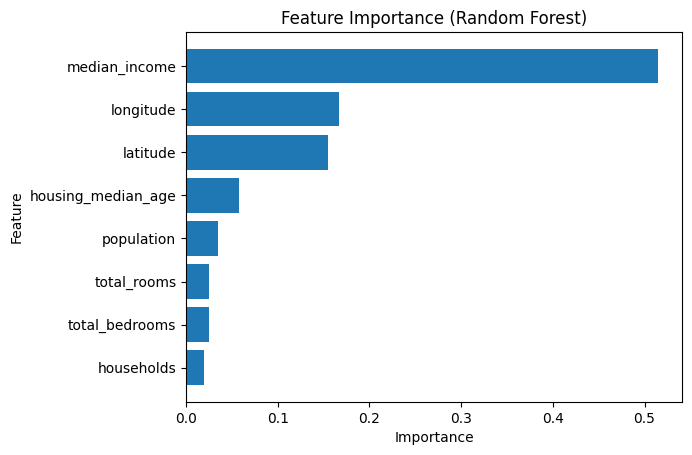


Sample Prediction:
Predicted Price: 148691.0
Actual Median House Value: 142700.0


In [1]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ================================
# 2. Load Dataset
# ================================
# Fix: The original file 'housing_price_dataset.csv' was not found.
# Please ensure the file is uploaded or provide the correct path.
# For demonstration, replacing with a sample dataset 'california_housing_train.csv'.
# Note: The subsequent feature engineering and model training steps might need adjustments
# to match the columns and data types of this new dataset.
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# ================================
# 3. Data Cleaning
# ================================

# Remove negative prices (invalid data)
# This step might need to be adjusted based on the actual columns of the new dataset.
# For 'california_housing_train.csv', 'median_house_value' is the target.
# Assuming a similar check might be needed for the target variable if negative values are possible.
# df = df[df['Price'] > 0] # Original line, commented out for sample dataset

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# ================================
# 4. Exploratory Data Analysis (EDA)
# ================================

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Correlation
corr = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(corr)

# Plot: Price Distribution
plt.figure()
# Original: df['Price'].hist()
# For 'california_housing_train.csv', use 'median_house_value'
df['median_house_value'].hist()
plt.title("Median House Value Distribution")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

# Plot: SquareFeet vs Price
plt.figure()
# Original: plt.scatter(df['SquareFeet'], df['Price'])
# For 'california_housing_train.csv', using 'total_rooms' as a proxy for size and 'median_house_value' for price.
plt.scatter(df['total_rooms'], df['median_house_value'])
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.title("Total Rooms vs Median House Value")
plt.show()

# ================================
# 5. Feature Engineering
# ================================

# One-hot encoding for Neighborhood
# Original: df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)
# 'california_housing_train.csv' has 'ocean_proximity' for categorical feature.
# The 'california_housing_train.csv' dataset does not contain an 'ocean_proximity' column.
# If you intend to encode a different categorical feature, please specify the column name.
# For now, this line will be commented out to prevent the KeyError.
# df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Features and target
# Original: X = df.drop("Price", axis=1)
# Original: y = df["Price"]
# For 'california_housing_train.csv', target is 'median_house_value'.
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# ================================
# 6. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# 7. Model 1: Linear Regression
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluation
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLinear Regression Performance:")
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

# ================================
# 8. Model 2: Random Forest
# ================================
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Performance:")
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print("R2:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

# ================================
# 9. Feature Importance (Important!)
# ================================
importances = rf.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance_df)

# Plot Feature Importance
plt.figure()
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# ================================
# 10. Sample Prediction
# ================================
sample = X_test.iloc[0:1]
prediction = rf.predict(sample)

print("\nSample Prediction:")
print("Predicted Price:", prediction[0])
# Original: print("Actual Price:", y_test.iloc[0])
print("Actual Median House Value:", y_test.iloc[0])


In [2]:
# House Price Prediction Using Machine Learning

# 1. Import required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Load dataset
data = pd.read_csv("housing_price_dataset.csv")

# 3. Display first few rows
print("First 5 rows of dataset:")
print(data.head())

print("\nDataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())


# 4. Define features and target
X = data.drop("Price", axis=1)
y = data["Price"]


# 5. Separate numerical and categorical columns
numerical_features = ["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]
categorical_features = ["Neighborhood"]


# 6. Preprocessing
# Scale numerical data and one-hot encode categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


# 7. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 8. Create models using pipelines
models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=42))
    ])
}


# 9. Train and evaluate models
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}")


# 10. Compare results in a table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("\nModel Comparison:")
print(results_df.sort_values(by="R2 Score", ascending=False))


# 11. Select best model manually (usually Random Forest performs well)
best_model = models["Random Forest"]
best_model.fit(X_train, y_train)


# 12. Predict price for a new house
new_house = pd.DataFrame({
    "SquareFeet": [2200],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Neighborhood": ["Urban"],
    "YearBuilt": [2005]
})

predicted_price = best_model.predict(new_house)
print("\nPredicted Price for New House:", predicted_price[0])

First 5 rows of dataset:
   SquareFeet  Bedrooms  Bathrooms Neighborhood  YearBuilt          Price
0        2126         4          1        Rural       1969  215355.283618
1        2459         3          2        Rural       1980  195014.221626
2        1860         2          1       Suburb       1970  306891.012076
3        2294         2          1        Urban       1996  206786.787153
4        2130         5          2       Suburb       2001  272436.239065

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3

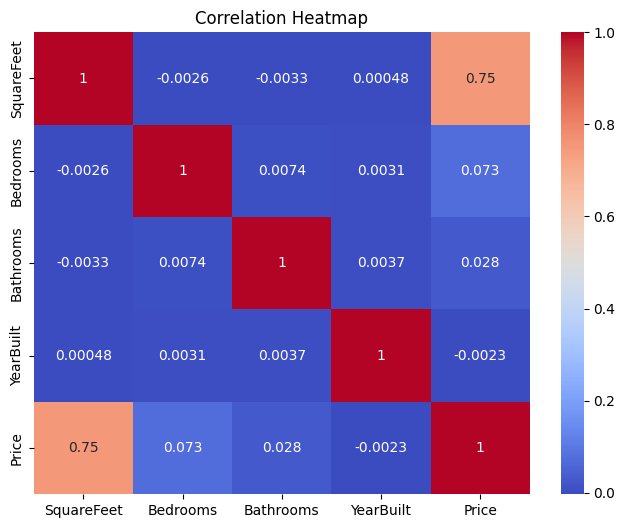

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

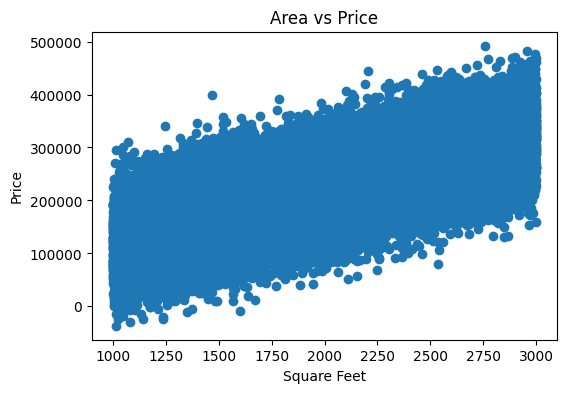

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(data["SquareFeet"], data["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

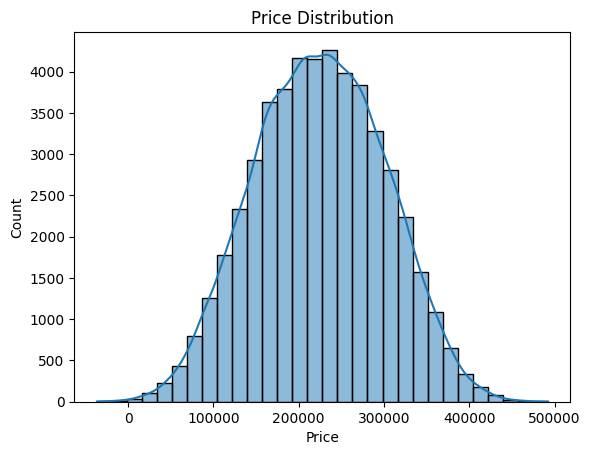

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["Price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

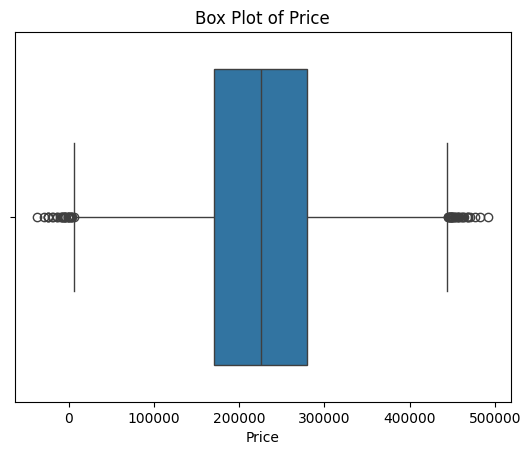

In [6]:
sns.boxplot(x=data["Price"])
plt.title("Box Plot of Price")
plt.show()

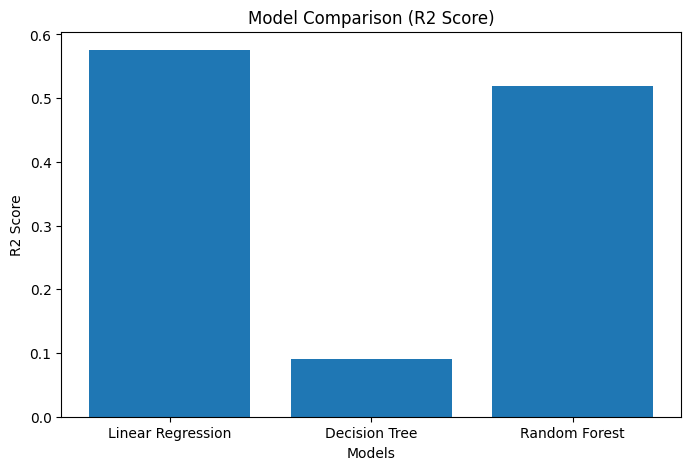

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

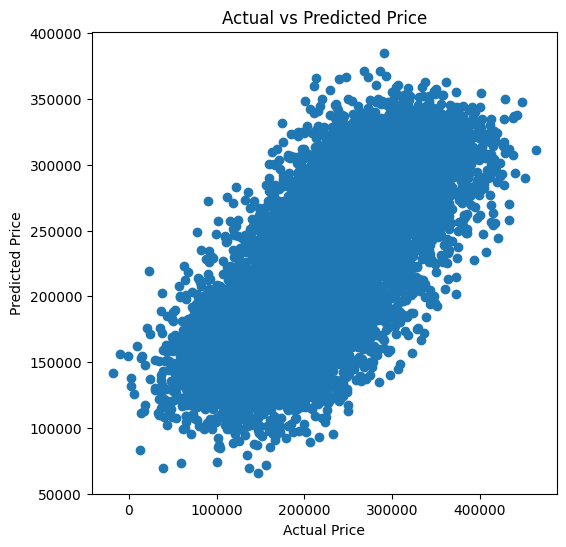

In [8]:
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

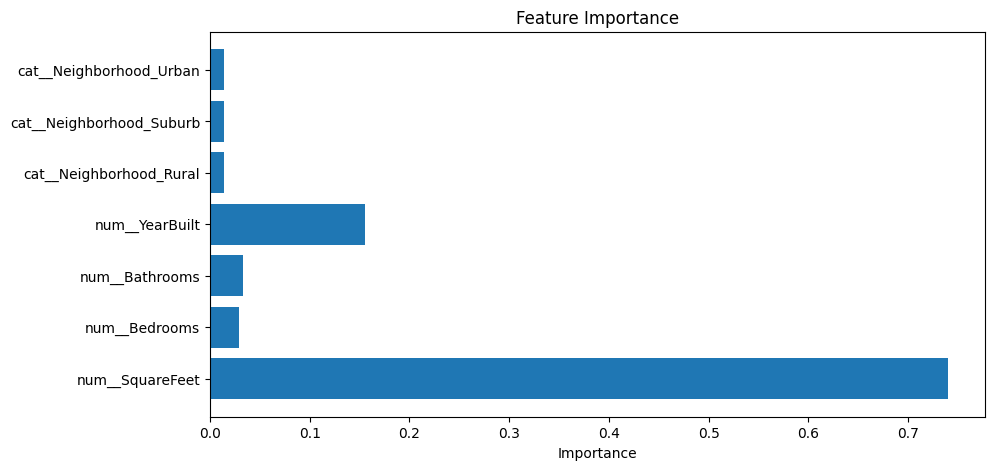

In [9]:
rf_model = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_

plt.figure(figsize=(10,5))
plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [11]:
# Hyperparameter Tuning for House Price Prediction

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load dataset
data = pd.read_csv("housing_price_dataset.csv")

# Features and target
X = data.drop("Price", axis=1)
y = data["Price"]

# Numerical and categorical features
numerical_features = ["SquareFeet", "Bedrooms", "Bathrooms", "YearBuilt"]
categorical_features = ["Neighborhood"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models and hyperparameters
models = {
    "Linear Regression": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", LinearRegression())
        ]),
        "params": {
            "model__fit_intercept": [True, False],
            "model__positive": [True, False]
        }
    },

    "Decision Tree": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        "params": {
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    }
}

# Store results
results = []
best_models = {}

# Hyperparameter tuning for all models
for model_name, model_info in models.items():
    print("\nTuning:", model_name)

    grid_search = GridSearchCV(
        estimator=model_info["pipeline"],
        param_grid=model_info["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_models[model_name] = best_model

    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Best Parameters": grid_search.best_params_,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print("Best Parameters:", grid_search.best_params_)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

# Results table
results_df = pd.DataFrame(results)

print("\nFinal Tuned Model Comparison:")
print(results_df[["Model", "MAE", "RMSE", "R2 Score"]])

# Select best model based on R2 Score
best_result = results_df.loc[results_df["R2 Score"].idxmax()]
best_model_name = best_result["Model"]

print("\nBest Model:", best_model_name)
print("Best R2 Score:", best_result["R2 Score"])

final_model = best_models[best_model_name]

# Predict new house price
new_house = pd.DataFrame({
    "SquareFeet": [2200],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "Neighborhood": ["Urban"],
    "YearBuilt": [2005]
})

predicted_price = final_model.predict(new_house)

print("\nPredicted Price for New House:", predicted_price[0])


Tuning: Linear Regression
Best Parameters: {'model__fit_intercept': True, 'model__positive': True}
MAE: 39431.84868666924
RMSE: 49359.80595653566
R2 Score: 0.5755382856951106

Tuning: Decision Tree
Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
MAE: 39601.905779498215
RMSE: 49601.12495537583
R2 Score: 0.5713777723135853

Tuning: Random Forest


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}
MAE: 39663.10710089148
RMSE: 49735.63803531874
R2 Score: 0.5690498624685532

Final Tuned Model Comparison:
               Model           MAE          RMSE  R2 Score
0  Linear Regression  39431.848687  49359.805957  0.575538
1      Decision Tree  39601.905779  49601.124955  0.571378
2      Random Forest  39663.107101  49735.638035  0.569050

Best Model: Linear Regression
Best R2 Score: 0.5755382856951106

Predicted Price for New House: 242594.52526879765
